In [1]:
import pandas as pd

In [3]:
df=pd.read_csv(r'C:\Users\MAIN POINT\Downloads\student\tested.csv')

In [4]:
print(df)

     PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    male  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                       Myles, Mr. Thomas Francis    male  62.0      0      0   
3                                Wirz, Mr. Albert    male  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
..                                            ...     ...

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [13]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [15]:
df=df.drop("Cabin",axis=1)

In [16]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex       Age  SibSp  \
0                                Kelly, Mr. James    male  34.50000      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.00000      1   
2                       Myles, Mr. Thomas Francis    male  62.00000      0   
3                                Wirz, Mr. Albert    male  27.00000      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.00000      1   
..                                         

In [17]:
df.groupby("Age")["Survived"].mean()

Age
0.17     1.000000
0.33     0.000000
0.75     0.000000
0.83     0.000000
0.92     1.000000
           ...   
62.00    0.000000
63.00    0.500000
64.00    0.666667
67.00    0.000000
76.00    1.000000
Name: Survived, Length: 80, dtype: float64

In [18]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.392157
Q    0.521739
S    0.325926
Name: Survived, dtype: float64

In [19]:
df["Family_Size"]=df["SibSp"] + df["Parch"] + 1

In [21]:
df.groupby("Family_Size")["Survived"].mean()

Family_Size
1     0.268775
2     0.486486
3     0.526316
4     0.714286
5     0.285714
6     0.666667
7     0.250000
8     0.500000
11    0.500000
Name: Survived, dtype: float64

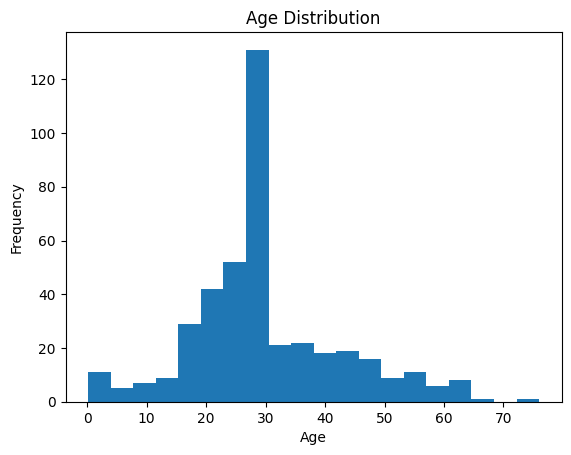

In [22]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [23]:
corr = df.corr(numeric_only=True)

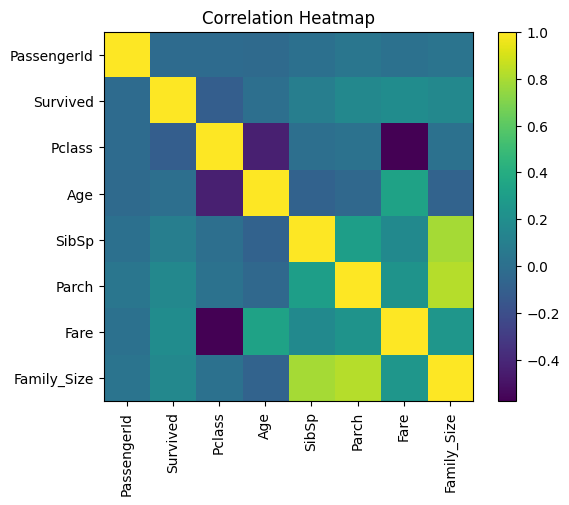

In [24]:

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

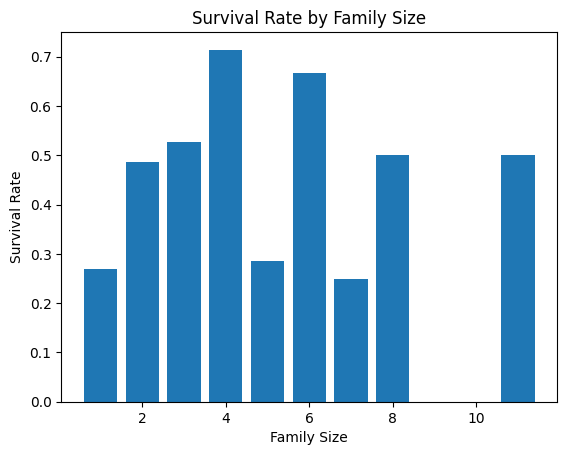

In [25]:
# Create Family Size
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1

import matplotlib.pyplot as plt

survival_by_family = df.groupby("Family_Size")["Survived"].mean()

plt.figure()
plt.bar(survival_by_family.index, survival_by_family.values)
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size")
plt.show()